# Тема 2. 
 > **Задание:** Моделирование связи частотного и классического определения вероятности
Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.


## Задача "извлечение карт из колоды"
Из стандартной колоды в 36 карт наудачу извлекаются 4 карты. Найти вероятность того, что среди извлеченных карт окажется ровно один туз.


Рассмотрим событие A - среди извлеченных 4 карт окажется ровно один туз.

Пользуясь классическим определением вероятности получим:

$$P(A) = \frac{C_4^1 \cdot C_{32}^3}{C_{36}^4}$$

In [1]:
#Классическая вероятность
import scipy.special as sc


p = sc.comb(4, 1) * sc.comb(32, 3) / sc.comb(36, 4)


print(f"Классическая вероятность P(A): {p:.4f}")

Классическая вероятность P(A): 0.3368


Частотная вероятность: 0.3353 


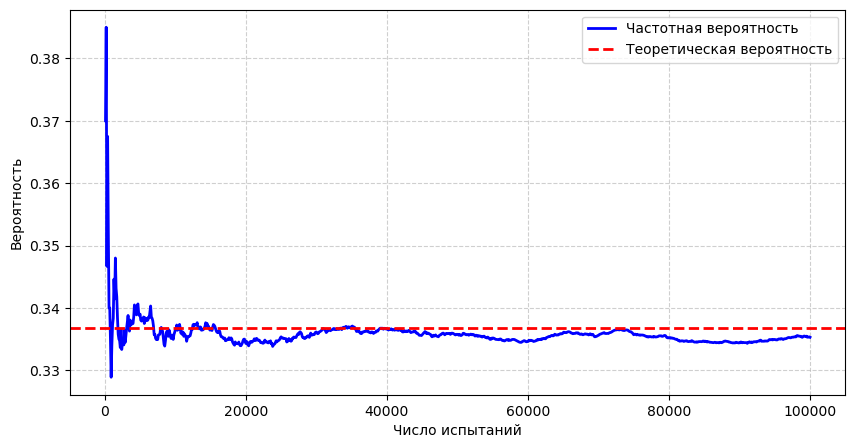

In [2]:
# Частотная вероятность
import numpy as np
import matplotlib.pyplot as plt

N = 100_000 
np.random.seed(42)  

# Колода: 4 туза (1) и 32 остальные карты (0)
deck = np.array([1] * 4 + [0] * 32)

successes = 0
freq = []
step_range = []

for i in range(1, N + 1):
    cards = np.random.choice(deck, size=4, replace=False)
    
    if np.sum(cards) == 1:
        successes += 1
        
    if i % 100 == 0:
        step_range.append(i)
        freq.append(successes / i)

p_a = successes / N


print(f"Частотная вероятность: {p_a:.4f} ")


plt.figure(figsize=(10, 5))
plt.plot(step_range, freq, label='Частотная вероятность', color='blue', linewidth=2)
plt.axhline(y=p, color='red', linestyle='--', linewidth=2, label=f'Теоретическая вероятность')

plt.xlabel('Число испытаний')
plt.ylabel('Вероятность')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()